# 12 — Full Strategy Comparison Backtest

## Purpose
This is the MASTER comparison notebook.
Every filter from notebooks 03–11 is evaluated here side-by-side.

## Methodology
- Same backtest engine for all scenarios (fair comparison)
- Same data period
- Same risk ($20 per trade)
- Same RR (2.0)
- Only the FILTERS change between scenarios

## Scenarios
1. **Baseline** — raw OB, no filters
2. **+ Session** — London + NY only
3. **+ Session + BOS** — structure break required
4. **+ Session + BOS + FVG** — imbalance required
5. **+ Session + BOS + FVG + Volume** — all confirmations
6. **+ Regime filter** — skip ranging markets
7. **FULL** — all filters active

## Decision rule
Keep a filter ONLY if it improves expectancy OR reduces max drawdown
WITHOUT reducing trade frequency below a usable level (< 1 trade/week).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

from strategy.ob_core import add_candle_features
from strategy.ob_signals import list_ob_signals_enhanced, OBSignalConfig, get_passed_signals

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (20, 8)})

SYMBOL    = 'BNBUSDT'
RISK_USDT = 20.0
RR        = 2.0
START_BAL = 10000.0

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
h1 = pd.read_csv(f'../notebooks/data/{SYMBOL}/H1/ohlcv.csv', index_col=0, parse_dates=True)

for df in [m5, h1]:
    df.index = pd.to_datetime(df.index, utc=True)

m5, h1 = m5.sort_index(), h1.sort_index()
m5 = add_candle_features(m5)

print(f'M5: {len(m5):,} bars | H1: {len(h1):,} bars')
print(f'Date range: {m5.index[0].date()} to {m5.index[-1].date()}')

M5: 159,999 bars | H1: 39,999 bars
Date range: 2024-11-07 to 2026-05-16


In [2]:
# ── Backtest engine ─────────────────────────────────────────────────────────
FEE_RATE = 0.00055  # 0.055% per side (entry + exit)

def backtest_signals(m5_df, signals_df, start_balance=10000.0, risk=20.0):
    """Simple fill-at-entry, evaluate TP/SL on subsequent bars."""
    trades = []
    balance = start_balance
    equity = [(m5_df.index[0], balance)]

    for _, sig in signals_df.iterrows():
        bar   = int(sig['signal_bar_index'])
        side  = sig['side']
        entry = float(sig['entry'])
        sl    = float(sig['sl'])
        tp    = float(sig['tp'])
        dist  = abs(entry - sl)
        qty   = risk / max(dist, 1e-9)

        result = None
        exit_p = None
        exit_t = None

        for j in range(bar + 1, min(bar + 300, len(m5_df))):
            b = m5_df.iloc[j]
            hit_sl = b['low'] <= sl if side == 'buy' else b['high'] >= sl
            hit_tp = b['high'] >= tp if side == 'buy' else b['low'] <= tp
            if hit_sl and hit_tp:
                exit_p, result = sl, 'loss'
            elif hit_sl:
                exit_p, result = sl, 'loss'
            elif hit_tp:
                exit_p, result = tp, 'win'
            if result:
                exit_t = m5_df.index[j]
                break

        if result is None:
            continue

        fee = (entry + exit_p) * qty * FEE_RATE
        pnl = ((exit_p - entry) * qty if side == 'buy' else (entry - exit_p) * qty) - fee
        balance += pnl
        equity.append((exit_t, balance))
        trades.append({'result': result, 'pnl': pnl, 'balance': balance,
                       'side': side, 'entry_time': m5_df.index[bar]})

    return pd.DataFrame(trades), pd.Series({t: v for t, v in equity})


def calc_metrics(trades_df, start_balance=10000.0):
    if trades_df.empty:
        return {k: None for k in ['trades','win_rate','expectancy','profit_factor','max_dd','total_pnl']}
    wins  = trades_df[trades_df['result']=='win']
    losses= trades_df[trades_df['result']=='loss']
    wr    = len(wins)/len(trades_df)
    aw    = wins['pnl'].mean() if len(wins) > 0 else 0
    al    = losses['pnl'].mean() if len(losses) > 0 else 0
    pf    = wins['pnl'].sum() / abs(losses['pnl'].sum()) if len(losses)>0 and losses['pnl'].sum()!=0 else 0
    dd    = 0.0
    peak  = start_balance
    for b in trades_df['balance']:
        peak = max(peak, b)
        dd   = max(dd, (peak - b) / peak * 100)
    return {
        'trades'        : len(trades_df),
        'win_rate'      : round(wr*100, 1),
        'expectancy'    : round(wr*aw + (1-wr)*al, 2),
        'profit_factor' : round(pf, 2),
        'max_dd'        : round(dd, 1),
        'total_pnl'     : round(trades_df['pnl'].sum(), 2),
    }

print('Backtest engine ready.')

Backtest engine ready.


In [3]:
# ── Define filter scenarios ────────────────────────────────────────────────
scenarios = {
    '01_baseline': OBSignalConfig(rr=RR),
    '02_session' : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  allow_london=True, allow_new_york=True, allow_overlap=True),
    '03_+bos'    : OBSignalConfig(rr=RR, session_filter_enabled=True, require_bos=True),
    '04_+fvg'    : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  require_bos=True, require_fvg=True),
    '05_+volume' : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  require_bos=True, require_fvg=True,
                                  volume_filter_enabled=True),
    '06_+regime' : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  require_bos=True, require_fvg=True,
                                  volume_filter_enabled=True, regime_filter_enabled=True),
    '07_full'    : OBSignalConfig(rr=RR, session_filter_enabled=True,
                                  require_bos=True, require_fvg=True,
                                  volume_filter_enabled=True, regime_filter_enabled=True,
                                  liquidity_sweep_filter=False),  # sweep optional
}

# ── Run all scenarios ──────────────────────────────────────────────────────
all_metrics = {}
all_trades  = {}
all_equities= {}

for name, cfg in scenarios.items():
    sigs = list_ob_signals_enhanced(m5, h1=h1, risk_cash=RISK_USDT, config=cfg)
    sigs_pass = get_passed_signals(sigs)
    trades, equity = backtest_signals(m5, sigs_pass, start_balance=START_BAL, risk=RISK_USDT)
    all_trades[name]   = trades
    all_equities[name] = equity
    m = calc_metrics(trades)
    all_metrics[name]  = m
    print(f'{name:20s}: trades={m["trades"]} WR={m["win_rate"]}% exp={m["expectancy"]} PF={m["profit_factor"]} DD={m["max_dd"]}%')

print('\nAll scenarios complete.')

01_baseline         : trades=4361 WR=50.4% exp=-2.49 PF=0.84 DD=108.1%
02_session          : trades=2504 WR=50.9% exp=-1.98 PF=0.87 DD=52.5%
03_+bos             : trades=1499 WR=49.5% exp=-2.55 PF=0.84 DD=38.6%
04_+fvg             : trades=992 WR=52.3% exp=-0.91 PF=0.94 DD=11.7%
05_+volume          : trades=394 WR=55.3% exp=0.45 PF=1.03 DD=3.4%
06_+regime          : trades=None WR=None% exp=None PF=None DD=None%
07_full             : trades=None WR=None% exp=None PF=None DD=None%

All scenarios complete.


In [4]:
# ── Metrics comparison table ────────────────────────────────────────────────
comparison = pd.DataFrame(all_metrics).T
comparison.index = [s.split('_', 1)[-1] for s in comparison.index]
print('\n=== STRATEGY COMPARISON ===')
print(comparison.to_string())

# Save results
os.makedirs('../notebooks_ob/results', exist_ok=True)
comparison.to_csv('../notebooks_ob/results/12_strategy_comparison.csv')
print('\nSaved to notebooks_ob/results/12_strategy_comparison.csv')


=== STRATEGY COMPARISON ===
          trades win_rate expectancy profit_factor max_dd total_pnl
baseline  4361.0     50.4      -2.49          0.84  108.1 -10867.26
session   2504.0     50.9      -1.98          0.87   52.5  -4955.85
+bos      1499.0     49.5      -2.55          0.84   38.6  -3828.36
+fvg       992.0     52.3      -0.91          0.94   11.7   -905.41
+volume    394.0     55.3       0.45          1.03    3.4    177.97
+regime     None     None       None          None   None      None
full        None     None       None          None   None      None

Saved to notebooks_ob/results/12_strategy_comparison.csv


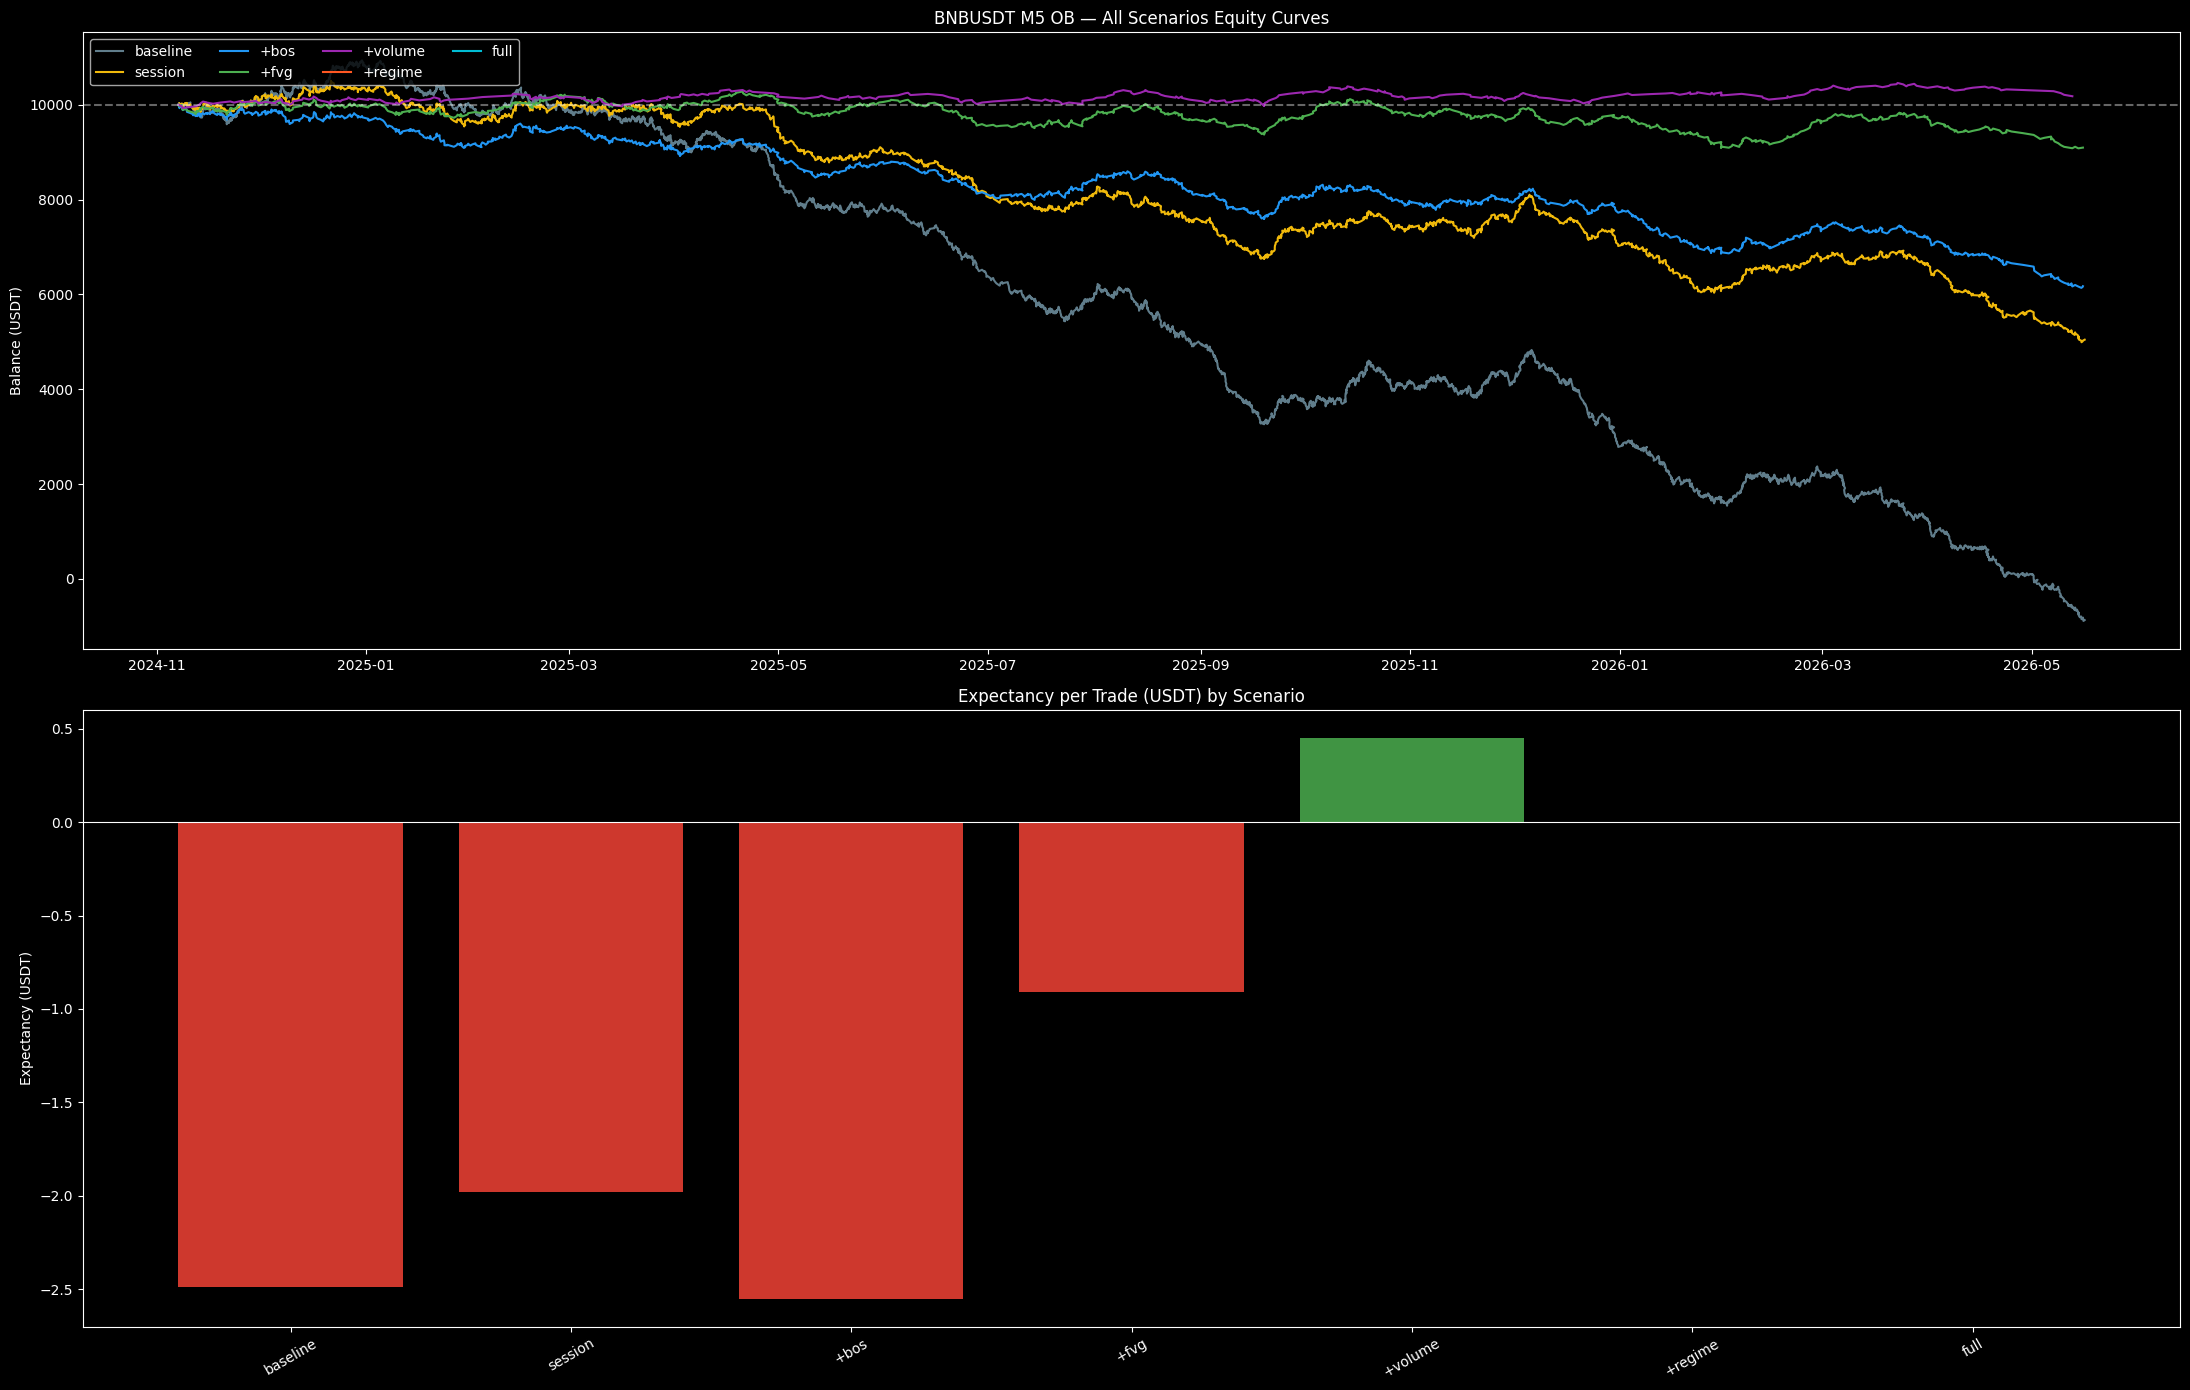


Best scenario: "+volume" with expectancy = $0.45 per trade
Use this scenario's OBSignalConfig in ob_trading_service.py


In [5]:
# ── Equity curve comparison ─────────────────────────────────────────────────
colors = ['#607D8B','#F0B90B','#2196F3','#4CAF50','#9C27B0','#FF5722','#00BCD4']

fig, axes = plt.subplots(2, 1, figsize=(22, 14))

# Equity curves
for (name, eq), color in zip(all_equities.items(), colors):
    label = name.split('_', 1)[-1]
    if not eq.empty:
        axes[0].plot(eq.index, eq.values, label=label, color=color, linewidth=1.5)

axes[0].axhline(START_BAL, color='white', linestyle='--', alpha=0.4)
axes[0].set_title(f'{SYMBOL} M5 OB — All Scenarios Equity Curves')
axes[0].set_ylabel('Balance (USDT)')
axes[0].legend(ncol=4, loc='upper left')

# Bar chart: expectancy by scenario
names  = [s.split('_', 1)[-1] for s in all_metrics]
expcts = [all_metrics[s]['expectancy'] or 0 for s in all_metrics]
bar_colors = ['#4CAF50' if e > 0 else '#F44336' for e in expcts]
axes[1].bar(names, expcts, color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='white', linewidth=0.8)
axes[1].set_title('Expectancy per Trade (USDT) by Scenario')
axes[1].set_ylabel('Expectancy (USDT)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../notebooks_ob/results/12_equity_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# Final recommendation
best = max(all_metrics, key=lambda k: all_metrics[k]['expectancy'] or -999)
best_label = best.split('_', 1)[-1]
best_exp   = all_metrics[best]['expectancy']
print(f'\nBest scenario: "{best_label}" with expectancy = ${best_exp:.2f} per trade')
print('Use this scenario\'s OBSignalConfig in ob_trading_service.py')